In [ ]:
%cd d:\Troida

import sys, os
project_root = os.path.abspath(".")
if project_root not in sys.path: sys.path.insert(0, project_root)

d:\Troida


In [ ]:
from types import SimpleNamespace

# настройки MACD/catboost, меняйте при необходимости
SETTINGS = SimpleNamespace(
    csv="./data/21.10.2024 13.00.00 - 21.10.2025 13.00.00/YDEX_2H_20241021_130000_20251021_130000.csv",
    lookback=1000,
    horizon=100,
    step=20,
    cost_bps=5.0,
    macd_fast="",
    macd_slow="",
    macd_signal="",
    cat_overrides="",
)

Карта классов:
0 {'fast': 8, 'slow': 20, 'signal': 5}
1 {'fast': 8, 'slow': 20, 'signal': 9}
2 {'fast': 8, 'slow': 26, 'signal': 5}
3 {'fast': 8, 'slow': 26, 'signal': 9}
4 {'fast': 8, 'slow': 30, 'signal': 5}
5 {'fast': 8, 'slow': 30, 'signal': 9}
6 {'fast': 12, 'slow': 20, 'signal': 5}
7 {'fast': 12, 'slow': 20, 'signal': 9}
8 {'fast': 12, 'slow': 26, 'signal': 5}
9 {'fast': 12, 'slow': 26, 'signal': 9}
10 {'fast': 12, 'slow': 30, 'signal': 5}
11 {'fast': 12, 'slow': 30, 'signal': 9}
12 {'fast': 16, 'slow': 20, 'signal': 5}
13 {'fast': 16, 'slow': 20, 'signal': 9}
14 {'fast': 16, 'slow': 26, 'signal': 5}
15 {'fast': 16, 'slow': 26, 'signal': 9}
16 {'fast': 16, 'slow': 30, 'signal': 5}
17 {'fast': 16, 'slow': 30, 'signal': 9}


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 2.8310532	test: 2.8332632	best: 2.8332632 (0)	total: 148ms	remaining: 9m 52s
100:	learn: 2.6360327	test: 2.7925438	best: 2.7925438 (100)	total: 611ms	remaining: 23.6s
200:	learn: 2.4499743	test: 2.7626369	best: 2.7621875 (197)	total: 973ms	remaining: 18.4s
300:	learn: 2.2588620	test: 2.7609286	best: 2.7595461 (284)	total: 1.32s	remaining: 16.2s
400:	learn: 2.0784484	test: 2.7677370	best: 2.7595461 (284)	total: 1.64s	remaining: 14.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 2.759546123
bestIteration = 284

Shrink model to first 285 iterations.
Holdout accuracy: 0.2
Рекомендованные параметры MACD: {'fast': 12, 'slow': 26, 'signal': 9}
Последнее форвард-окно:
  Рекомендация: Sharpe=-0.128, Sum=-0.0625
  База 12-26-9: Sharpe=-0.128, Sum=-0.0625


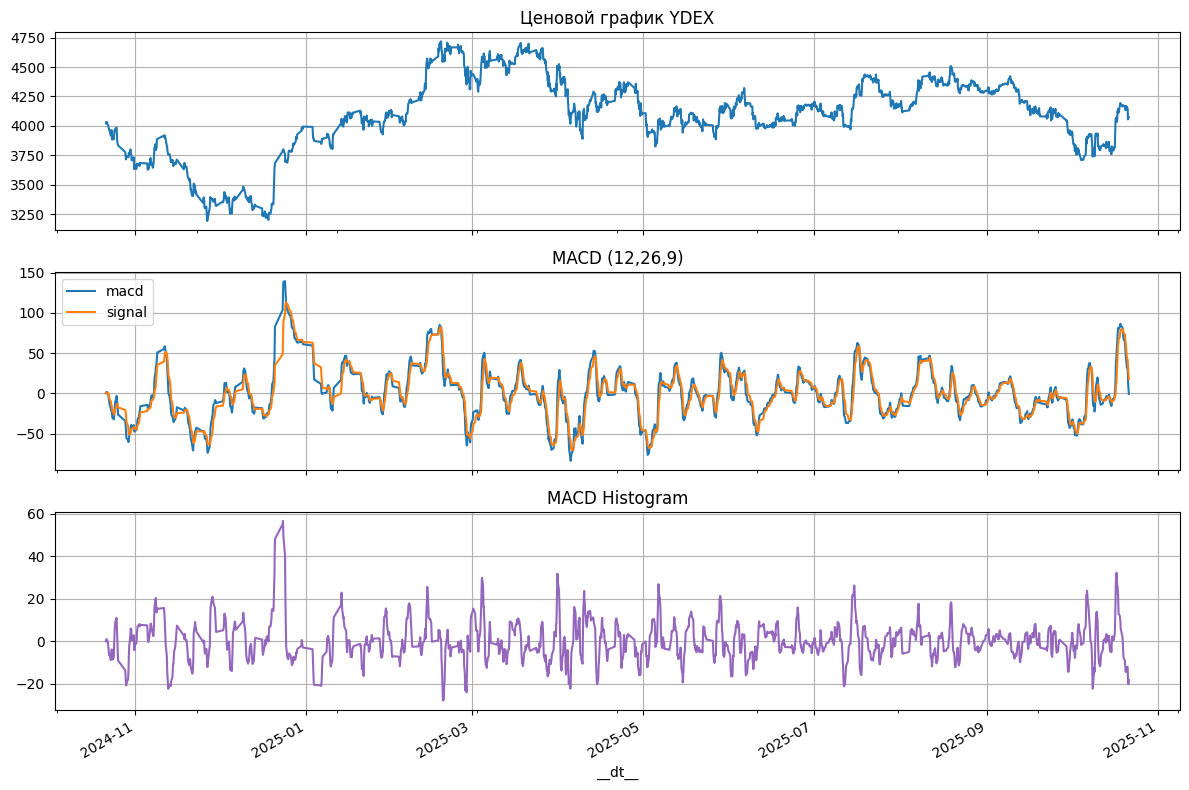

Лучшие параметры MACD: {'fast': 12, 'slow': 26, 'signal': 9}


In [ ]:
from types import SimpleNamespace
from macd import run_pipeline, compute_macd
import matplotlib.pyplot as plt

args = SimpleNamespace(
    csv=SETTINGS.csv,
    lookback=SETTINGS.lookback,
    horizon=SETTINGS.horizon,
    step=SETTINGS.step,
    cost_bps=SETTINGS.cost_bps,
    macd_fast=SETTINGS.macd_fast,
    macd_slow=SETTINGS.macd_slow,
    macd_signal=SETTINGS.macd_signal,
    cat_overrides=SETTINGS.cat_overrides,
    plot=True,
)
result = run_pipeline(args, verbose=True)

asset_name = os.path.basename(SETTINGS.csv).split('_')[0]
df = result["df"]
best_params = result["best_params"]
macd_full = compute_macd(df["close"], best_params["fast"], best_params["slow"], best_params["signal"])

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
df["close"].plot(ax=ax[0], title=f"Ценовой график {asset_name}")
ax[0].grid(True)

macd_full[["macd", "signal"]].plot(ax=ax[1], title=f"MACD ({best_params['fast']},{best_params['slow']},{best_params['signal']})")
ax[1].grid(True)

macd_full["hist"].plot(ax=ax[2], color="tab:purple", title="MACD Histogram")
ax[2].grid(True)

plt.tight_layout()
plt.show()
print("Лучшие параметры MACD:", best_params)